# NY TaxiAID — EDA
### Yellow Taxi Trip Records · mayo 2022 · formato Parquet

Predecir **tarifa** (`fare_amount`) y **duración** (minutos) de un viaje en taxi en NYC,
usando únicamente información disponible **al inicio del viaje**.

**Estructura del notebook**

0. Install dependencies
1. Get data, establish parameters, create custom columns
2. Clean data
3. Explore the data
4. Find patterns & relationships
5. Visualize the insights
6. Generate business insights

## 0. Install dependencies

Instalamos las librerías y fijamos las opciones de visualización. `pyarrow` es el motor que
pandas usa para leer Parquet, así que es obligatorio aunque no lo importemos directamente.

In [2]:
# Descomentar la primera vez que se corre el notebook.
%pip install pandas pyarrow numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Opciones de visualización: todas las columnas visibles y 2 decimales en los números
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 3.0.6 | numpy 2.5.3


## 1. Get data, establish parameters, create custom columns

### 1.1 Parámetros

Todos los valores configurables viven en un solo lugar. Cuando este notebook se convierta en
`src/config.py`, los seis miembros del equipo importarán exactamente los mismos umbrales y los
resultados serán comparables entre sí.

In [6]:
# --- Rutas -------------------------------------------------------------------
DATA_PATH  = "../data/raw/yellow_tripdata_2022-05.parquet"
ZONES_PATH = "../data/raw/taxi_zone_lookup.csv"   # opcional, para nombres de zona

# --- Período esperado --------------------------------------------------------
PERIODO_INICIO = pd.Timestamp("2022-05-01")
PERIODO_FIN    = pd.Timestamp("2022-06-01")    # exclusivo

# --- Ventanas horarias (definidas por el equipo) -----------------------------
MORNING_RUSH = (7, 9)      # 7:00 a 9:59
NIGHT_RUSH   = (17, 19)    # 17:00 a 19:59
WEEKEND_DAYS = (5, 6)      # sábado y domingo (lunes = 0)

# --- Umbrales de validez física ----------------------------------------------
MIN_DURACION, MAX_DURACION = 1, 180      # minutos
MIN_DISTANCIA, MAX_DISTANCIA = 0.1, 100  # millas
MIN_TARIFA = 2.50                        # bajada de bandera oficial NYC 2022
MAX_TARIFA = 500
MIN_VELOCIDAD, MAX_VELOCIDAD = 1, 80     # mph

# --- Códigos de referencia (diccionario TLC) ---------------------------------
RATE_NEGOCIADA = 5         # tarifa acordada, no depende de distancia ni tiempo
RATE_DESCONOCIDO = 99
ZONAS_DESCONOCIDAS = [264, 265]
AEROPUERTOS = {132: "JFK", 138: "LaGuardia", 1: "Newark"}

# --- Reproducibilidad --------------------------------------------------------
RANDOM_STATE = 42
SAMPLE_SIZE = 200_000      # muestra para los gráficos pesados

### 1.2 Cargar los datos

Parquet guarda los tipos de dato dentro del archivo, así que las fechas llegan ya como
`datetime` y no hace falta `parse_dates`. También es mucho más rápido y liviano que CSV,
que es la razón por la que el equipo eligió este formato.

In [7]:
df = pd.read_parquet(DATA_PATH)

# El nombre de la columna de tarifa de aeropuerto cambia entre años: lo normalizamos
df = df.rename(columns={"Airport_fee": "airport_fee"})

print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
df.head()

Filas: 3,588,295 | Columnas: 19
Memoria: 548.9 MB


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.00,4.10,1.00,N,246,151,2,17.00,3.00,0.50,0.00,0.00,0.30,20.80,2.50,0.00
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.00,2.30,1.00,N,238,74,2,11.00,3.00,0.50,0.00,0.00,0.30,14.80,2.50,0.00
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.00,4.20,1.00,N,163,260,2,15.50,3.00,0.50,0.00,0.00,0.30,19.30,2.50,0.00
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.00,0.00,1.00,N,79,182,1,41.20,0.00,0.50,0.00,0.00,0.30,42.00,0.00,0.00
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.00,1.60,1.00,N,238,75,1,7.50,3.00,0.50,2.25,0.00,0.30,13.55,2.50,0.00


### 1.3 Clasificar las columnas

Separamos las columnas en tres grupos. Este es el paso más importante de todo el proyecto:
las columnas de `LEAKAGE` solo existen **cuando el viaje ya terminó**, así que usarlas como
features produciría un modelo con métricas excelentes en el notebook e inservible en la API.

In [8]:
# Lo que queremos predecir
TARGETS = ["fare_amount", "duration_min"]

# Información disponible cuando el usuario pide la estimación
FEATURES_BASE = [
    "VendorID", "tpep_pickup_datetime", "passenger_count", "trip_distance",
    "RatecodeID", "PULocationID", "DOLocationID",
]

# Solo existe al terminar el viaje: NO puede entrar al modelo
LEAKAGE = [
    "tpep_dropoff_datetime", "payment_type", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "congestion_surcharge", "airport_fee", "store_and_fwd_flag",
]

sin_clasificar = set(df.columns) - set(TARGETS + FEATURES_BASE + LEAKAGE)
print("Columnas sin clasificar:", sin_clasificar or "ninguna")

Columnas sin clasificar: ninguna


### 1.4 Crear columnas derivadas

Construimos tres familias de columnas:

- **Target de duración:** no viene en el dataset, hay que calcularlo restando las marcas del taxímetro.
- **Variables de diagnóstico** (`avg_speed_mph`, `fare_per_mile`): no son features, porque usan la
  duración o la tarifa, que son justamente lo que queremos predecir. Sirven para **detectar errores**:
  un viaje a 200 mph o a 800 dólares por milla es imposible.
- **Features temporales** (`morning_rush`, `night_rush`, `weekend_rush`, etc.): sí son features válidas,
  porque se conocen antes de arrancar. Son el núcleo del enfoque de series temporales del proyecto.

In [9]:
# --- Targets -----------------------------------------------------------------
# La duración no existe en el dataset: se deriva de las dos marcas del taxímetro
df["duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# --- Variables de diagnóstico (NO son features) ------------------------------
horas = df["duration_min"] / 60
df["avg_speed_mph"] = np.where(horas > 0, df["trip_distance"] / horas, np.nan)
df["fare_per_mile"] = np.where(df["trip_distance"] > 0,
                               df["fare_amount"] / df["trip_distance"], np.nan)

# --- Features temporales (SÍ son features: se conocen al inicio) -------------
pickup = df["tpep_pickup_datetime"]
df["pickup_date"]  = pickup.dt.date
df["pickup_hour"]  = pickup.dt.hour
df["pickup_dow"]   = pickup.dt.dayofweek          # 0 = lunes ... 6 = domingo
df["pickup_day"]   = pickup.dt.day
df["pickup_week"]  = pickup.dt.isocalendar().week.astype("int16")

# Banderas de congestión definidas por el equipo
df["morning_rush"] = df["pickup_hour"].between(*MORNING_RUSH)
df["night_rush"]   = df["pickup_hour"].between(*NIGHT_RUSH)
df["is_weekend"]   = df["pickup_dow"].isin(WEEKEND_DAYS)
# weekend_rush: viaje de fin de semana (según la definición acordada del equipo)
df["weekend_rush"] = df["is_weekend"]
# Bandera resumen: ¿el viaje cae en alguna ventana de congestión entre semana?
df["any_rush"] = (df["morning_rush"] | df["night_rush"]) & ~df["is_weekend"]

# Franja del día: versión categórica, útil para agrupar y graficar
df["time_segment"] = pd.cut(
    df["pickup_hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["madrugada", "mañana", "mediodía", "tarde", "noche"],
)

# Segmento combinado: es la variable que usaremos en los heat maps del punto 5
def segmento_rush(row):
    if row["is_weekend"]:
        return "weekend"
    if row["morning_rush"]:
        return "morning rush"
    if row["night_rush"]:
        return "night rush"
    return "off-peak"

df["rush_segment"] = np.select(
    [df["is_weekend"], df["morning_rush"], df["night_rush"]],
    ["weekend", "morning rush", "night rush"],
    default="off-peak",
)

# --- Features de ubicación ---------------------------------------------------
df["pu_airport"] = df["PULocationID"].map(AEROPUERTOS)     # NaN si no es aeropuerto
df["do_airport"] = df["DOLocationID"].map(AEROPUERTOS)
df["is_airport_trip"] = df["pu_airport"].notna() | df["do_airport"].notna()
df["same_zone"] = df["PULocationID"] == df["DOLocationID"]
df["unknown_zone"] = (df["PULocationID"].isin(ZONAS_DESCONOCIDAS)
                      | df["DOLocationID"].isin(ZONAS_DESCONOCIDAS))

nuevas = ["duration_min", "avg_speed_mph", "fare_per_mile", "pickup_hour", "pickup_dow",
          "morning_rush", "night_rush", "weekend_rush", "any_rush", "rush_segment",
          "time_segment", "is_airport_trip", "same_zone", "unknown_zone"]
print(f"Columnas creadas: {len(nuevas)}")
df[["duration_min", "avg_speed_mph", "fare_per_mile", "rush_segment"]].head()

Columnas creadas: 14


,duration_min,avg_speed_mph,fare_per_mile,rush_segment
0,18.70,13.16,4.15,weekend
1,13.82,9.99,4.78,weekend
2,15.37,16.40,3.69,weekend
3,39.73,0.00,NaN,weekend
4,9.38,10.23,4.69,weekend


**Otras columnas que podrían sumarse más adelante**, y que dejamos anotadas para el equipo:

- `is_holiday`: el 30 de mayo de 2022 fue Memorial Day, un lunes con tráfico atípico.
- `distancia_entre_centroides`: distancia geográfica entre zonas, usando el shapefile de TLC.
  Serviría como sustituto de `trip_distance` en producción, donde solo se tiene una estimación.
- Variables de clima (entregable opcional del proyecto, vía OpenWeather API).
- `trips_last_hour_in_zone`: demanda reciente por zona. Ojo: debe calcularse solo con datos
  pasados para no introducir leakage.

## 2. Clean data

Trabajamos sobre una copia (`clean`) y llevamos un registro de cuántas filas elimina cada regla.
Esa trazabilidad es lo que permite justificar la limpieza ante el mentor y los stakeholders.

In [10]:
clean = df.copy()
registro = []   # aquí anotamos el efecto de cada paso

def anotar(paso, antes, despues):
    """Guarda cuántas filas se perdieron en un paso y lo imprime."""
    perdidas = antes - despues
    registro.append({"paso": paso, "filas_antes": antes, "filas_despues": despues,
                     "eliminadas": perdidas, "pct": perdidas / antes * 100})
    print(f"{paso}: -{perdidas:,} filas ({perdidas / antes:.2%})")

### 2.1 Handle missing values

Primero medimos **cuántos** nulos hay y, sobre todo, **si aparecen juntos**. Si varias columnas
fallan siempre en las mismas filas, no son descuidos al azar sino un bloque de registros que se
generó de otra manera, y eso cambia por completo la decisión.

In [11]:
# Conteo de nulos por columna
nulos = clean.isna().sum().to_frame("nulos")
nulos["pct"] = nulos["nulos"] / len(clean) * 100
display(nulos[nulos["nulos"] > 0].sort_values("pct", ascending=False))

# ¿Los nulos aparecen juntos? Contamos las combinaciones de columnas vacías
cols_nulas = [c for c in nulos[nulos["nulos"] > 0].index if c not in ["avg_speed_mph", "fare_per_mile"]]
if cols_nulas:
    print("\nCombinaciones de nulos más frecuentes (True = dato faltante):")
    display(clean[cols_nulas].isna().value_counts().head(5))

,nulos,pct
do_airport,3464330,96.55
pu_airport,3306996,92.16
passenger_count,129524,3.61
RatecodeID,129524,3.61
store_and_fwd_flag,129524,3.61
congestion_surcharge,129524,3.61
airport_fee,129524,3.61
fare_per_mile,46438,1.29
avg_speed_mph,3030,0.08



Combinaciones de nulos más frecuentes (True = dato faltante):


passenger_count  RatecodeID  store_and_fwd_flag  congestion_surcharge  airport_fee  pu_airport  do_airport
False            False       False               False                 False        True        True          3083831
                                                                                    False       True           263897
True             True        True                True                  True         True        True           116029
False            False       False               False                 False        True        False           94279
                                                                                    False       False           16764
Name: count, dtype: int64

In [12]:
# Diagnóstico: ¿el bloque de nulos se comporta distinto al resto?
bloque = clean["RatecodeID"].isna()

print("Medianas por grupo (True = registro sin metadatos):")
display(clean.groupby(bloque)[["fare_amount", "trip_distance", "duration_min"]].median())

print("\nOrigen del bloque por proveedor:")
display(pd.crosstab(clean["VendorID"], bloque))

Medianas por grupo (True = registro sin metadatos):


,fare_amount,trip_distance,duration_min
RatecodeID,,,
False,10.50,1.90,12.52
True,17.86,3.62,18.03



Origen del bloque por proveedor:


RatecodeID,False,True
VendorID,,
1,1040604,13526
2,2418167,109830
5,0,14
6,0,6154


**Decisión:** conservar estas filas. Son viajes reales, más largos y caros que el promedio, y
provienen de los proveedores principales. Eliminarlos sesgaría el modelo justo contra el tipo de
viaje donde una buena estimación tiene más valor. En su lugar los marcamos con una bandera.

In [13]:
antes = len(clean)

# Bandera que le dice al modelo "este registro llegó incompleto"
clean["sin_metadatos"] = clean["RatecodeID"].isna()

# passenger_count: se imputa con 1, que es el valor más frecuente
clean["passenger_count"] = clean["passenger_count"].fillna(1)

# RatecodeID: los nulos se unen al código 99, que TLC ya usa para "desconocido"
clean["RatecodeID"] = clean["RatecodeID"].fillna(RATE_DESCONOCIDO)

# store_and_fwd_flag: categoría propia en vez de nulo
clean["store_and_fwd_flag"] = clean["store_and_fwd_flag"].fillna("U")

anotar("2.1 Nulos (imputados, sin eliminar filas)", antes, len(clean))

2.1 Nulos (imputados, sin eliminar filas): -0 filas (0.00%)


### 2.2 Remove duplicates

Las filas idénticas inflan artificialmente ciertos patrones y, peor aún, si caen a ambos lados del
split train/test el modelo evalúa sobre datos que ya vio entrenando, lo que infla las métricas.

In [14]:
antes = len(clean)
duplicados = clean.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicados:,}")

clean = clean.drop_duplicates()
anotar("2.2 Duplicados", antes, len(clean))

Filas completamente duplicadas: 0
2.2 Duplicados: -0 filas (0.00%)


### 2.3 Fix incorrect formats

Convertimos cada columna al tipo que le corresponde. Los códigos (`VendorID`, `RatecodeID`) son
categorías disfrazadas de números: dejarlos como float haría que un modelo lineal interprete que
el código 4 es "el doble" del 2, lo cual no significa nada.

In [15]:
# Códigos: enteros pequeños (Int16 admite nulos, a diferencia de int16)
for col in ["VendorID", "RatecodeID", "payment_type", "PULocationID",
            "DOLocationID", "passenger_count"]:
    clean[col] = clean[col].astype("Int16")

# Banderas de texto: categoría
clean["store_and_fwd_flag"] = clean["store_and_fwd_flag"].astype("category")
clean["rush_segment"] = clean["rush_segment"].astype("category")

# Montos: float32 es suficiente y ocupa la mitad que float64
for col in ["fare_amount", "trip_distance", "duration_min", "avg_speed_mph", "total_amount"]:
    clean[col] = clean[col].astype("float32")

print(clean.dtypes)
print(f"\nMemoria: {clean.memory_usage(deep=True).sum() / 1e6:,.1f} MB")

VendorID                          Int16
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   Int16
trip_distance                   float32
RatecodeID                        Int16
store_and_fwd_flag             category
PULocationID                      Int16
DOLocationID                      Int16
payment_type                      Int16
fare_amount                     float32
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float32
congestion_surcharge            float64
airport_fee                     float64
duration_min                    float32
avg_speed_mph                   float32
fare_per_mile                   float64
pickup_date                      object
pickup_hour                       int32
pickup_dow                        int32


### 2.4 Standardize inconsistent data

Aquí aplicamos las reglas de validez. El criterio no es estadístico sino **físico**: la pregunta no
es "¿este valor es raro?" sino "¿este viaje pudo haber ocurrido?". Un viaje de 90 minutos a JFK en
hora pico es extremo pero real, y el modelo necesita aprenderlo; uno de 90 minutos a 0.2 mph es un
taxímetro que quedó abierto.

In [16]:
# Inventario de cada regla ANTES de aplicarlas, para poder justificar la limpieza
fuera_periodo = ~clean["tpep_pickup_datetime"].between(
    PERIODO_INICIO, PERIODO_FIN, inclusive="left")

reglas = {
    "fecha fuera de mayo 2022":  fuera_periodo,
    "duración fuera de rango":   ~clean["duration_min"].between(MIN_DURACION, MAX_DURACION),
    "distancia fuera de rango":  ~clean["trip_distance"].between(MIN_DISTANCIA, MAX_DISTANCIA),
    "tarifa fuera de rango":     ~clean["fare_amount"].between(MIN_TARIFA, MAX_TARIFA),
    "velocidad imposible":       ~clean["avg_speed_mph"].between(MIN_VELOCIDAD, MAX_VELOCIDAD),
    "tarifa negociada (rate 5)": clean["RatecodeID"] == RATE_NEGOCIADA,
}

inventario = pd.DataFrame({
    "registros": {k: int(v.fillna(True).sum()) for k, v in reglas.items()}
})
inventario["pct"] = inventario["registros"] / len(clean) * 100
display(inventario.sort_values("registros", ascending=False))

,registros,pct
velocidad imposible,59767,1.67
distancia fuera de rango,58603,1.63
duración fuera de rango,54028,1.51
tarifa negociada (rate 5),28382,0.79
tarifa fuera de rango,22491,0.63
fecha fuera de mayo 2022,143,0.00


In [17]:
antes = len(clean)

# Regla 1: el viaje debe pertenecer al período analizado
clean = clean[~fuera_periodo.reindex(clean.index, fill_value=True)]

# Regla 2: validez física de duración, distancia y velocidad
clean = clean[
    clean["duration_min"].between(MIN_DURACION, MAX_DURACION)
    & clean["trip_distance"].between(MIN_DISTANCIA, MAX_DISTANCIA)
    & clean["avg_speed_mph"].between(MIN_VELOCIDAD, MAX_VELOCIDAD)
]

# Regla 3: la tarifa no puede ser menor que la bajada de bandera
clean = clean[clean["fare_amount"].between(MIN_TARIFA, MAX_TARIFA)]

anotar("2.4 Validez física y período", antes, len(clean))

2.4 Validez física y período: -90,097 filas (2.51%)


**Las tarifas negociadas se tratan aparte.** El precio lo acuerda una persona antes de arrancar, así
que no depende de la distancia ni del tiempo y es imposible de aprender para el modelo de tarifa.
Todos los outliers extremos que encontramos (0.10 millas por 450 dólares, 87 millas por 0.01) son de
este tipo. Para el modelo de **duración**, en cambio, son viajes perfectamente válidos: la tarifa no
interviene. Por eso cada modelo recibe un dataset distinto.

In [18]:
# Dataset para el modelo de DURACIÓN: incluye las negociadas
clean_duration = clean.copy()

# Dataset para el modelo de TARIFA: excluye las negociadas
clean_fare = clean[clean["RatecodeID"] != RATE_NEGOCIADA].copy()

print(f"Original:          {len(df):,} filas")
print(f"Dataset duración:  {len(clean_duration):,} filas ({len(clean_duration)/len(df):.2%})")
print(f"Dataset tarifa:    {len(clean_fare):,} filas ({len(clean_fare)/len(df):.2%})")

print("\nRegistro de limpieza:")
display(pd.DataFrame(registro))

Original:          3,588,295 filas
Dataset duración:  3,498,198 filas (97.49%)
Dataset tarifa:    3,488,484 filas (97.22%)

Registro de limpieza:


,paso,filas_antes,filas_despues,eliminadas,pct
0,"2.1 Nulos (imputados, sin eliminar filas)",3588295,3588295,0,0.00
1,2.2 Duplicados,3588295,3588295,0,0.00
2,2.4 Validez física y período,3588295,3498198,90097,2.51


## 3. Explore the data

### 3.1 Calculate summary statistics

Los percentiles extremos (1 y 99) muestran si todavía queda algún valor implausible después de la
limpieza. Comparar la media con la mediana revela cuánta asimetría hay: si la media es bastante
mayor, la cola derecha pesa mucho.

In [19]:
cols_resumen = ["trip_distance", "duration_min", "fare_amount",
                "avg_speed_mph", "fare_per_mile", "passenger_count"]

resumen = clean_fare[cols_resumen].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).T
resumen["skew"] = clean_fare[cols_resumen].skew()   # asimetría: 0 = simétrica
display(resumen)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,skew
trip_distance,"3,488,484.00",3.67,4.50,0.10,0.37,1.20,2.00,3.77,15.95,20.19,98.30,2.65
duration_min,"3,488,484.00",16.57,13.35,1.00,2.25,7.87,12.83,20.65,43.23,68.73,179.82,2.31
fare_amount,"3,488,484.00",14.90,12.64,2.50,4.00,7.50,10.50,16.95,52.00,54.00,430.00,2.52
avg_speed_mph,"3,488,484.00",11.99,6.48,1.00,3.51,7.77,10.31,14.19,25.30,35.75,79.72,1.86
fare_per_mile,"3,488,484.00",5.57,4.05,0.17,2.64,4.05,5.12,6.43,9.32,13.33,833.33,55.92
passenger_count,"3,488,484.00",1.38,0.94,0.00,0.00,1.00,1.00,1.00,3.00,6.00,6.00,2.82


### 3.2 Check data distribution

Ambos targets tienen cola larga a la derecha: muchos viajes cortos y baratos, pocos muy largos.
Esto anticipa dos cosas: conviene probar una transformación logarítmica del target, y el MAE y el
RMSE van a contar historias distintas, porque el RMSE castiga mucho más los errores grandes.

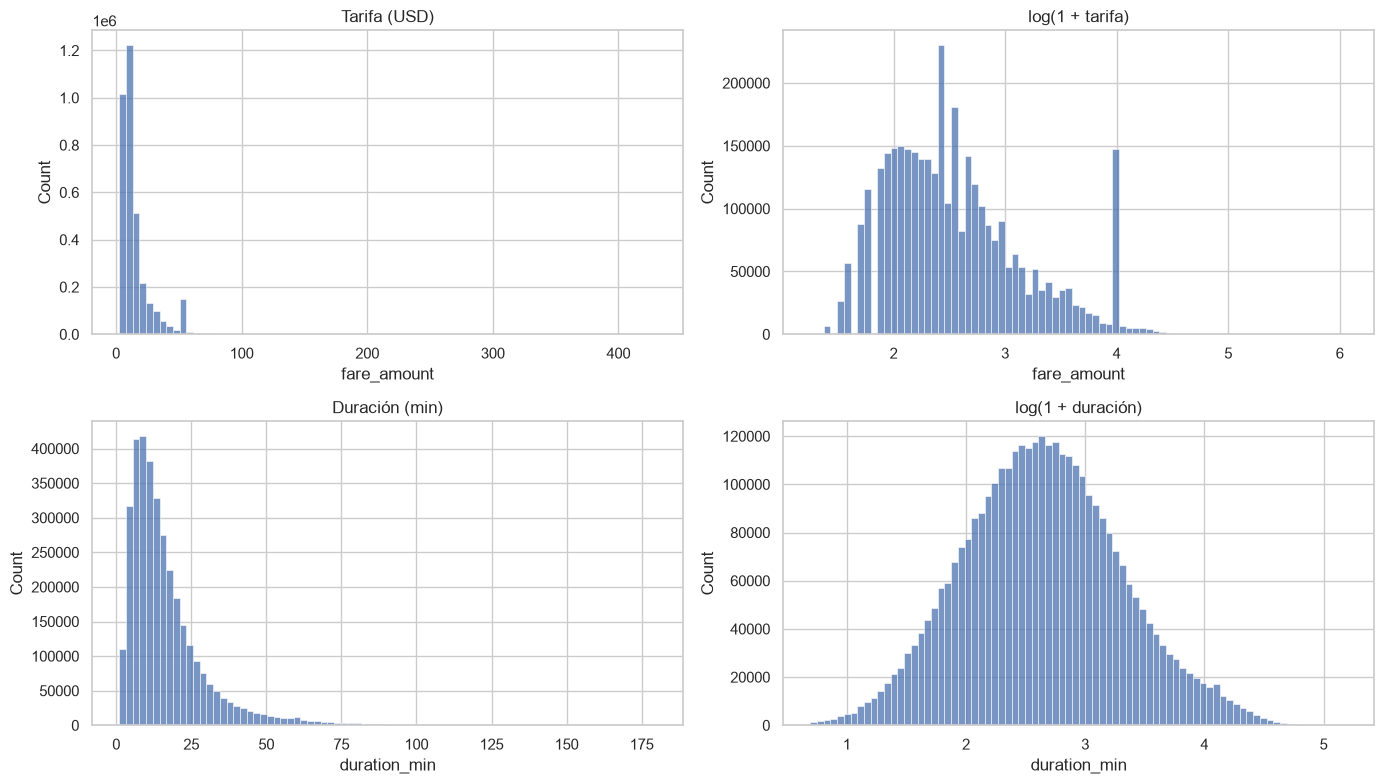

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Escala original: se ve la cola larga
sns.histplot(clean_fare["fare_amount"], bins=80, ax=axes[0, 0]).set_title("Tarifa (USD)")
sns.histplot(clean_fare["duration_min"], bins=80, ax=axes[1, 0]).set_title("Duración (min)")

# Escala logarítmica: la distribución se vuelve casi normal
sns.histplot(np.log1p(clean_fare["fare_amount"]), bins=80, ax=axes[0, 1]).set_title("log(1 + tarifa)")
sns.histplot(np.log1p(clean_fare["duration_min"]), bins=80, ax=axes[1, 1]).set_title("log(1 + duración)")

plt.tight_layout()
plt.show()

### 3.3 Identify key variables

Medimos qué tanto separa cada variable candidata a los targets. Para las numéricas usamos
correlación de Spearman (no exige relación lineal) y para las categóricas comparamos las medianas
entre grupos: si una variable no cambia la mediana, aporta poca señal al modelo.

In [21]:
muestra = clean_fare.sample(n=min(SAMPLE_SIZE, len(clean_fare)), random_state=RANDOM_STATE)

# Variables numéricas: correlación con cada target
num_feats = ["trip_distance", "passenger_count", "pickup_hour", "pickup_dow"]
corr_targets = muestra[num_feats + TARGETS].astype(float).corr(method="spearman")[TARGETS]
print("Correlación de Spearman con los targets:")
display(corr_targets.drop(TARGETS))

# Variables categóricas: ¿cambian la mediana del target?
for col in ["rush_segment", "is_airport_trip", "sin_metadatos", "RatecodeID"]:
    g = (clean_fare.groupby(col, observed=True)
         .agg(viajes=("fare_amount", "size"),
              tarifa_mediana=("fare_amount", "median"),
              duracion_mediana=("duration_min", "median"),
              velocidad_mediana=("avg_speed_mph", "median")))
    print(f"\n=== {col} ===")
    display(g)

Correlación de Spearman con los targets:


,fare_amount,duration_min
trip_distance,0.94,0.86
passenger_count,0.02,0.03
pickup_hour,-0.01,-0.00
pickup_dow,0.01,-0.01



=== rush_segment ===


,viajes,tarifa_mediana,duracion_mediana,velocidad_mediana
rush_segment,,,,
morning rush,318425,10.00,12.57,9.90
night rush,524947,10.00,12.87,9.32
off-peak,1703463,10.50,13.18,10.08
weekend,941649,10.50,12.28,11.49



=== is_airport_trip ===


,viajes,tarifa_mediana,duracion_mediana,velocidad_mediana
is_airport_trip,,,,
False,3120398,9.50,11.75,9.75
True,368086,44.00,36.83,21.82



=== sin_metadatos ===


,viajes,tarifa_mediana,duracion_mediana,velocidad_mediana
sin_metadatos,,,,
False,3364233,10.50,12.63,10.25
True,124251,17.61,18.48,12.12



=== RatecodeID ===


,viajes,tarifa_mediana,duracion_mediana,velocidad_mediana
RatecodeID,,,,
1,3202025,10.00,12.12,10.00
2,139548,52.00,49.42,22.00
3,10488,69.00,40.65,25.85
4,4449,65.00,34.37,33.47
6,4,5.50,6.62,13.64
99,131970,18.10,19.00,12.04


## 4. Find patterns & relationships

### 4.1 Analyze trends over time

El proyecto tiene enfoque de series temporales, así que estos patrones son la base de las features
de tiempo. Además, la evolución diaria nos dice si el mes es estable o si hay días atípicos que
convendría revisar antes del split train/test.

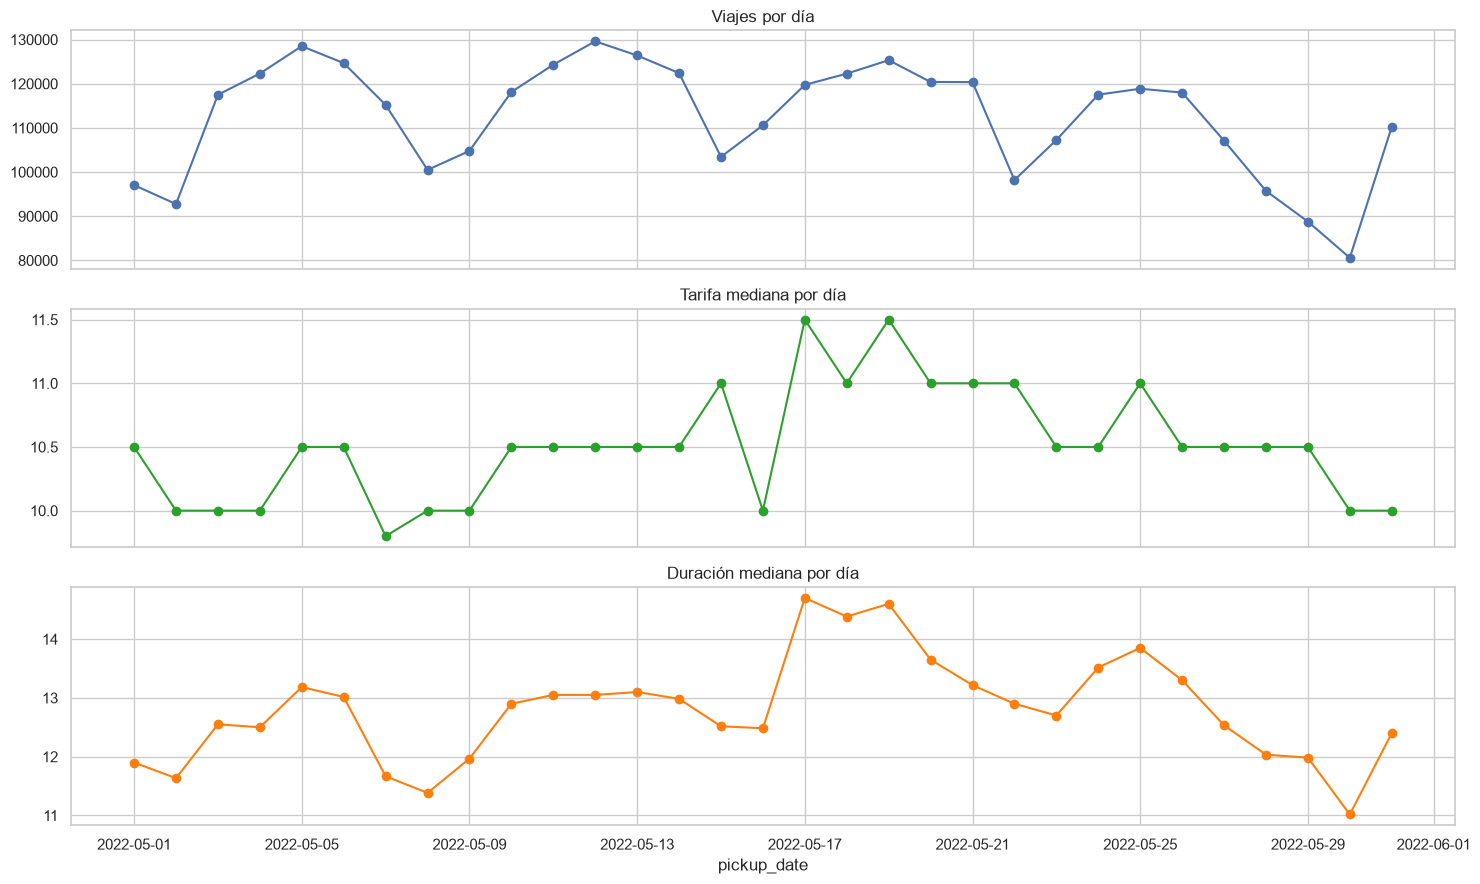

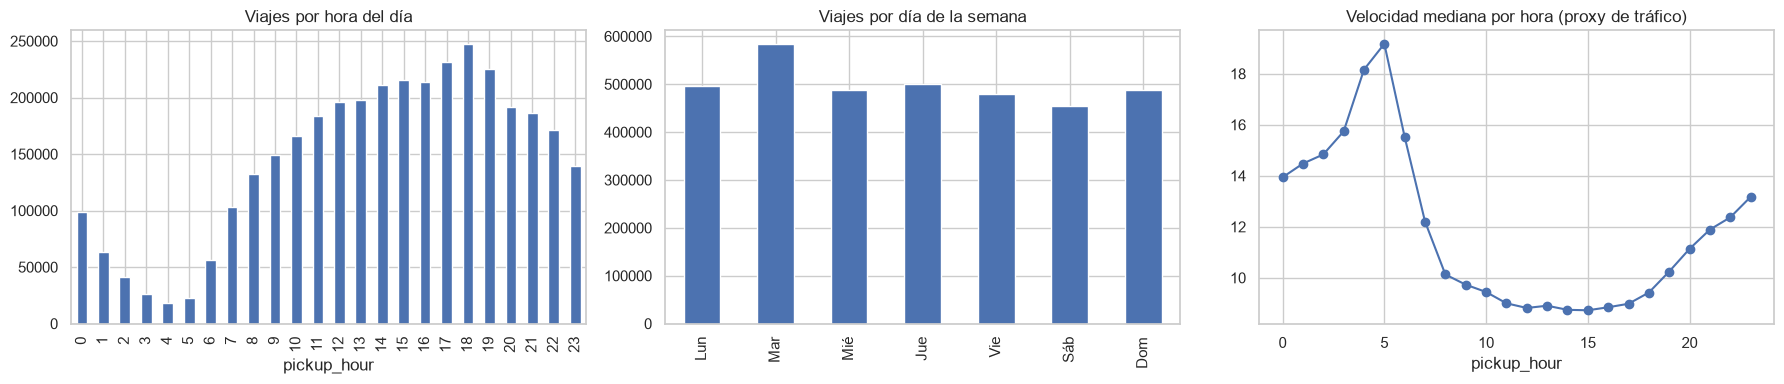

In [22]:
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

# Serie diaria: volumen y comportamiento a lo largo del mes
diario = clean_fare.groupby("pickup_date").agg(
    viajes=("fare_amount", "size"),
    tarifa=("fare_amount", "median"),
    duracion=("duration_min", "median"),
)

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
diario["viajes"].plot(ax=axes[0], marker="o", title="Viajes por día")
diario["tarifa"].plot(ax=axes[1], marker="o", color="tab:green", title="Tarifa mediana por día")
diario["duracion"].plot(ax=axes[2], marker="o", color="tab:orange", title="Duración mediana por día")
plt.tight_layout()
plt.show()

# Perfil por hora y día de la semana
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
por_hora = clean_fare.groupby("pickup_hour").size()
por_hora.plot(kind="bar", ax=axes[0], title="Viajes por hora del día")

por_dow = clean_fare.groupby("pickup_dow").size()
por_dow.index = dias
por_dow.plot(kind="bar", ax=axes[1], title="Viajes por día de la semana")

vel_hora = clean_fare.groupby("pickup_hour")["avg_speed_mph"].median()
vel_hora.plot(marker="o", ax=axes[2], title="Velocidad mediana por hora (proxy de tráfico)")
plt.tight_layout()
plt.show()

### 4.2 Check correlations

Mostramos dos matrices por separado y a propósito. La primera es la de las features legítimas. La
segunda es la de las columnas con leakage, y existe para dejar documentado **por qué** las excluimos
a pesar de ser las más predictivas de todas. Esa tabla es la defensa del equipo cuando alguien
pregunte por qué no usaron `total_amount`.

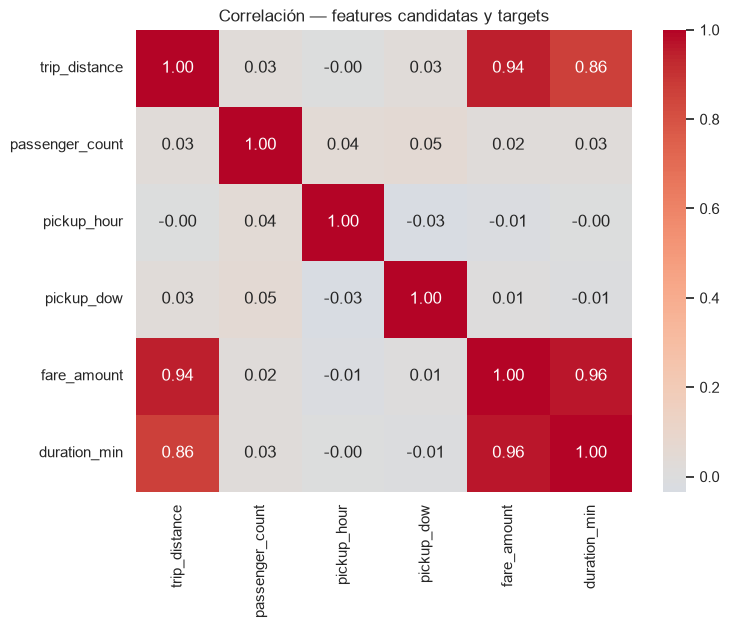

Correlación de las columnas con LEAKAGE (excluidas del modelo):


,fare_amount,duration_min
total_amount,0.97,0.93
tip_amount,0.47,0.44
tolls_amount,0.44,0.40
airport_fee,0.42,0.37
improvement_surcharge,-0.01,-0.01
extra,-0.06,-0.05
payment_type,-0.09,-0.06
mta_tax,-0.09,-0.08
congestion_surcharge,-0.19,-0.14


In [23]:
# Matriz 1: features candidatas y targets
corr_cols = ["trip_distance", "passenger_count", "pickup_hour", "pickup_dow",
             "fare_amount", "duration_min"]
plt.figure(figsize=(8, 6))
sns.heatmap(muestra[corr_cols].astype(float).corr(method="spearman"),
            annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación — features candidatas y targets")
plt.show()

# Matriz 2: columnas con leakage (solo para documentar la exclusión)
leak_num = [c for c in LEAKAGE if c in muestra.columns
            and muestra[c].dtype.kind in "if"]
leak_corr = (muestra[leak_num + TARGETS].astype(float)
             .corr(method="spearman")[TARGETS].drop(TARGETS))
print("Correlación de las columnas con LEAKAGE (excluidas del modelo):")
display(leak_corr.sort_values("fare_amount", ascending=False))

### 4.3 Identify outliers

Comparamos dos criterios. El **estadístico** (IQR) marca todo lo que se aleja del centro; el
**físico** marca lo imposible. En este dataset el IQR es demasiado agresivo: eliminaría viajes
largos a aeropuertos que son perfectamente reales y que el modelo necesita ver.

In [24]:
def limites_iqr(serie, k=1.5):
    """Devuelve los límites inferior y superior del criterio IQR clásico."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

comparacion = []
for col, fisico in [("fare_amount", (MIN_TARIFA, MAX_TARIFA)),
                    ("duration_min", (MIN_DURACION, MAX_DURACION)),
                    ("trip_distance", (MIN_DISTANCIA, MAX_DISTANCIA))]:
    lo, hi = limites_iqr(clean_fare[col])
    comparacion.append({
        "columna": col,
        "IQR_min": round(lo, 2), "IQR_max": round(hi, 2),
        "IQR_marca_%": round((~clean_fare[col].between(lo, hi)).mean() * 100, 2),
        "físico_min": fisico[0], "físico_max": fisico[1],
    })
display(pd.DataFrame(comparacion))

# Los viajes que el IQR descartaría: ¿son basura o son viajes caros reales?
lo_f, hi_f = limites_iqr(clean_fare["fare_amount"])
caros = clean_fare[clean_fare["fare_amount"] > hi_f]
print(f"\nViajes que el IQR marcaría como outliers de tarifa: {len(caros):,}")
print(f"De ellos, con origen o destino en aeropuerto: {caros['is_airport_trip'].mean():.1%}")
display(caros[["trip_distance", "duration_min", "fare_amount", "avg_speed_mph"]].median().to_frame("mediana"))

,columna,IQR_min,IQR_max,IQR_marca_%,físico_min,físico_max
0,fare_amount,-6.68,31.13,9.95,2.50,500
1,duration_min,-11.31,39.82,6.13,1.00,180
2,trip_distance,-2.65,7.62,12.72,0.10,100



Viajes que el IQR marcaría como outliers de tarifa: 347,045
De ellos, con origen o destino en aeropuerto: 80.1%


,mediana
trip_distance,16.00
duration_min,42.33
fare_amount,52.00
avg_speed_mph,20.40


## 5. Visualize the insights

### 5.1 Histograms — distribution

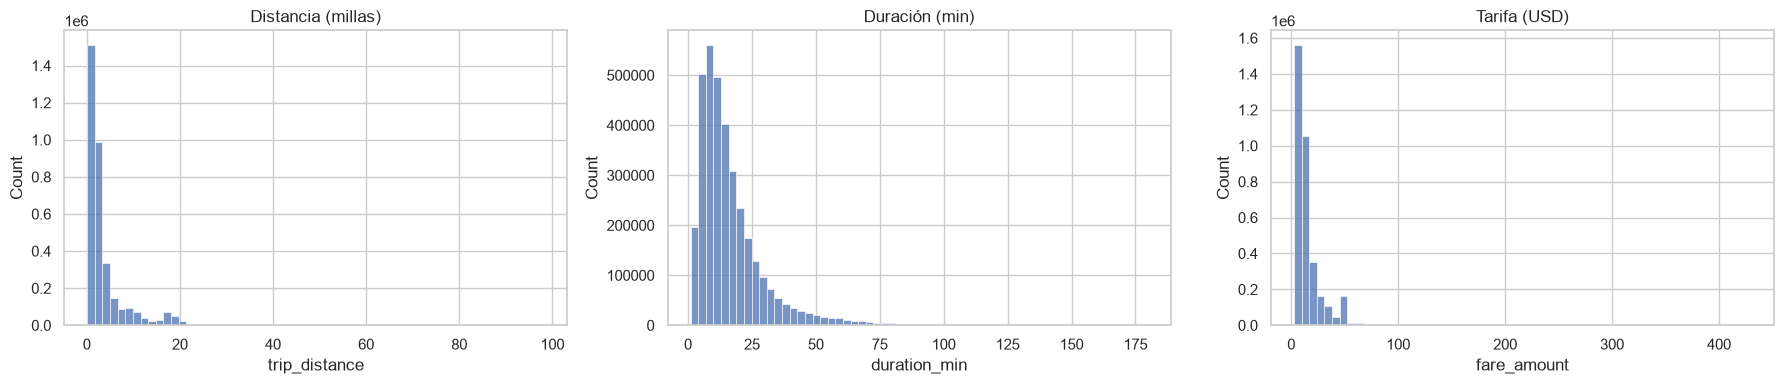

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(clean_fare["trip_distance"], bins=60, ax=axes[0]).set_title("Distancia (millas)")
sns.histplot(clean_fare["duration_min"], bins=60, ax=axes[1]).set_title("Duración (min)")
sns.histplot(clean_fare["fare_amount"], bins=60, ax=axes[2]).set_title("Tarifa (USD)")
plt.tight_layout()
plt.show()

### 5.2 Box plots — spread & outliers

El box plot por segmento responde directamente la pregunta de negocio: ¿cuánto varía la tarifa
dentro de cada franja horaria? Mientras más alta la caja, más difícil le será al modelo acertar
en ese segmento.

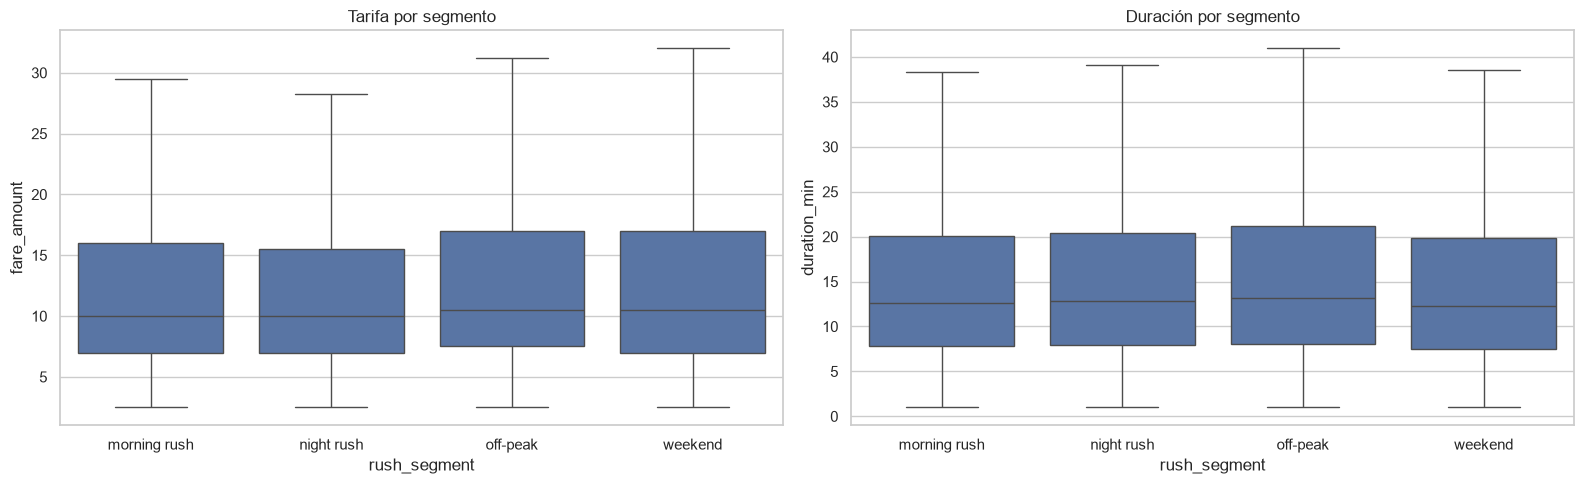

In [26]:
orden = ["morning rush", "night rush", "off-peak", "weekend"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=clean_fare, x="rush_segment", y="fare_amount",
            order=orden, showfliers=False, ax=axes[0])
axes[0].set_title("Tarifa por segmento")
sns.boxplot(data=clean_fare, x="rush_segment", y="duration_min",
            order=orden, showfliers=False, ax=axes[1])
axes[1].set_title("Duración por segmento")
plt.tight_layout()
plt.show()

### 5.3 Bar charts — comparison

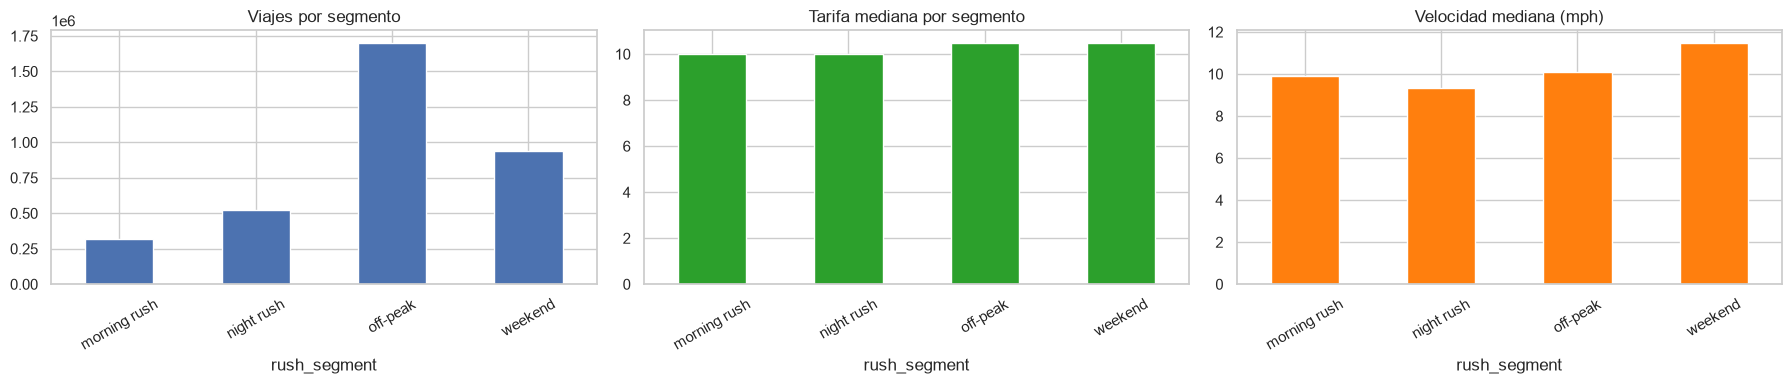

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

seg = clean_fare.groupby("rush_segment", observed=True).agg(
    viajes=("fare_amount", "size"),
    tarifa=("fare_amount", "median"),
    velocidad=("avg_speed_mph", "median"),
).reindex(orden)

seg["viajes"].plot(kind="bar", ax=axes[0], title="Viajes por segmento")
seg["tarifa"].plot(kind="bar", ax=axes[1], color="tab:green", title="Tarifa mediana por segmento")
seg["velocidad"].plot(kind="bar", ax=axes[2], color="tab:orange", title="Velocidad mediana (mph)")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 5.4 Scatter plots — relationships

El color separa los segmentos horarios. Lo esperable es que la tarifa suba casi linealmente con la
distancia (el taxímetro), mientras que la duración se dispersa mucho más, porque depende del
tráfico. Esa diferencia anticipa que la duración será el target más difícil de predecir.

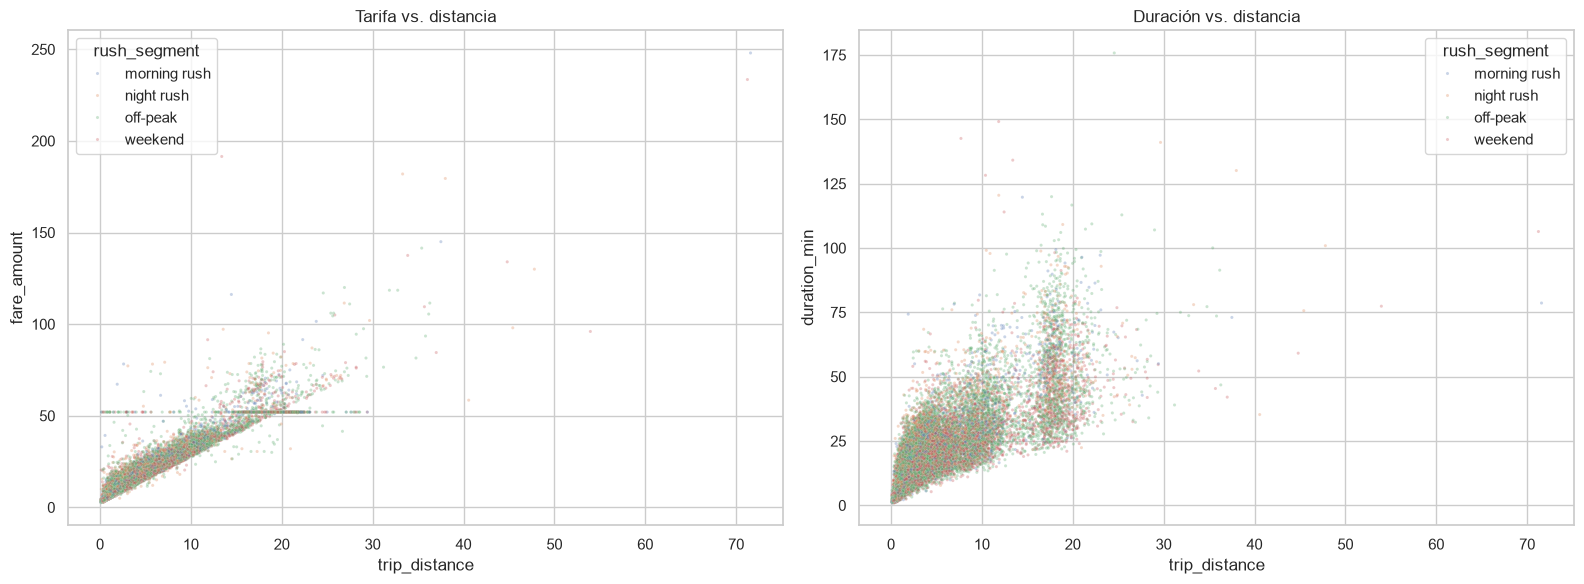

In [28]:
sc = muestra.sample(n=min(40_000, len(muestra)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=sc, x="trip_distance", y="fare_amount", hue="rush_segment",
                hue_order=orden, s=5, alpha=0.3, ax=axes[0])
axes[0].set_title("Tarifa vs. distancia")
sns.scatterplot(data=sc, x="trip_distance", y="duration_min", hue="rush_segment",
                hue_order=orden, s=5, alpha=0.3, ax=axes[1])
axes[1].set_title("Duración vs. distancia")
plt.tight_layout()
plt.show()

### 5.5 Heat maps

Los dos primeros mapas cruzan hora del día contra día de la semana. El tercero y el cuarto
responden de forma directa a las preguntas del esquema: cómo se comportan la tarifa y la duración
en cada segmento de congestión, controlando por la distancia del viaje. Controlar por distancia es
clave: sin eso no se sabe si un segmento es más caro por el tráfico o simplemente porque la gente
hace viajes más largos.

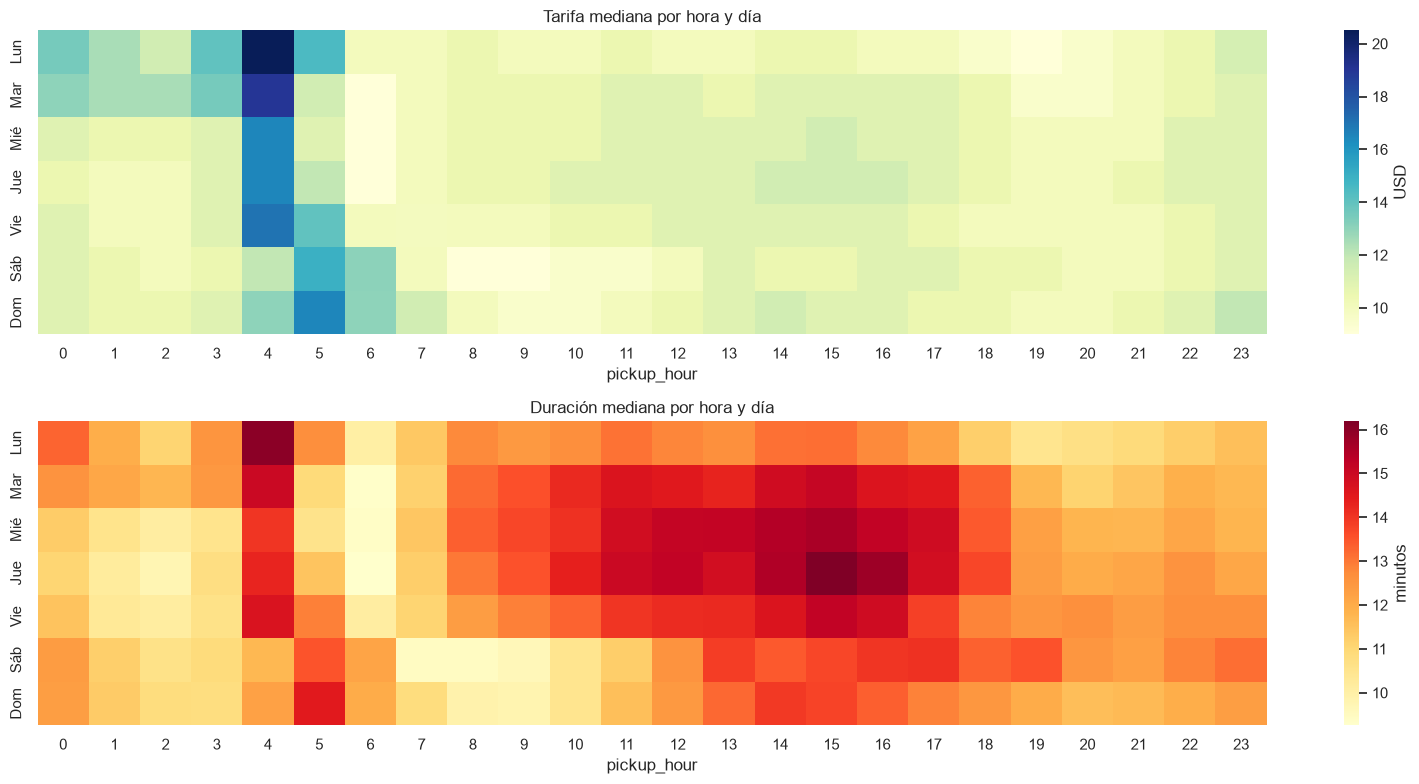

In [29]:
# Mapa 1 y 2: hora x día de la semana
piv_tarifa = clean_fare.pivot_table(index="pickup_dow", columns="pickup_hour",
                                    values="fare_amount", aggfunc="median")
piv_dur = clean_fare.pivot_table(index="pickup_dow", columns="pickup_hour",
                                 values="duration_min", aggfunc="median")
piv_tarifa.index = dias
piv_dur.index = dias

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
sns.heatmap(piv_tarifa, cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "USD"})
axes[0].set_title("Tarifa mediana por hora y día")
sns.heatmap(piv_dur, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "minutos"})
axes[1].set_title("Duración mediana por hora y día")
plt.tight_layout()
plt.show()

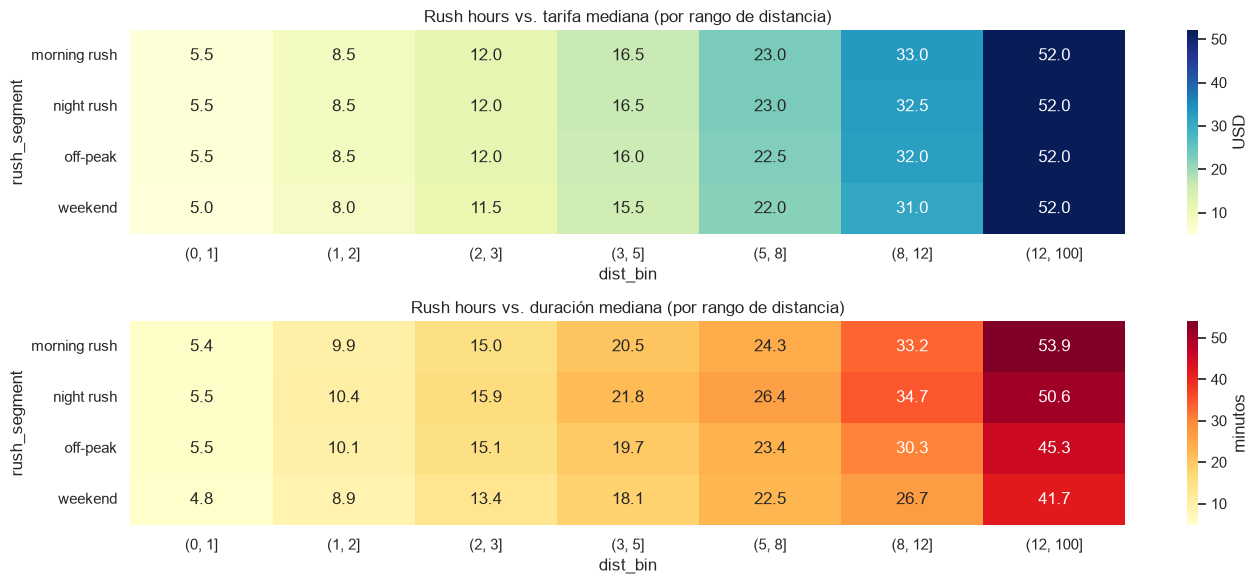

In [30]:
# Mapa 3 y 4: segmento de congestión x rango de distancia
# El binning se hace en una copia temporal: las columnas de intervalos no se
# pueden guardar en Parquet, así que no deben quedar en el dataset final
binned = clean_fare.assign(
    dist_bin=pd.cut(clean_fare["trip_distance"], bins=[0, 1, 2, 3, 5, 8, 12, 100])
)

piv_rush_fare = binned.pivot_table(index="rush_segment", columns="dist_bin",
                                       values="fare_amount", aggfunc="median",
                                       observed=True).reindex(orden)
piv_rush_dur = binned.pivot_table(index="rush_segment", columns="dist_bin",
                                      values="duration_min", aggfunc="median",
                                      observed=True).reindex(orden)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
sns.heatmap(piv_rush_fare, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0],
            cbar_kws={"label": "USD"})
axes[0].set_title("Rush hours vs. tarifa mediana (por rango de distancia)")
sns.heatmap(piv_rush_dur, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            cbar_kws={"label": "minutos"})
axes[1].set_title("Rush hours vs. duración mediana (por rango de distancia)")
plt.tight_layout()
plt.show()

## 6. Generate business insights

### 6.1 Identify key takeaways

Esta celda calcula los números concretos que van a la presentación. La idea es no escribir
conclusiones a mano: que salgan de los datos y se actualicen solas si cambia la limpieza.

In [31]:
print("=" * 60)
print("HALLAZGOS CLAVE — NY TaxiAID / mayo 2022")
print("=" * 60)

print(f"\nVolumen: {len(df):,} viajes en el archivo original")
print(f"Dataset utilizable para tarifa: {len(clean_fare):,} ({len(clean_fare)/len(df):.1%})")
print(f"Dataset utilizable para duración: {len(clean_duration):,} ({len(clean_duration)/len(df):.1%})")

print(f"\nViaje típico: {clean_fare['trip_distance'].median():.1f} millas, "
      f"{clean_fare['duration_min'].median():.0f} min, "
      f"USD {clean_fare['fare_amount'].median():.2f}")

# Impacto de la congestión, controlando por distancia (viajes de 2 a 5 millas)
medios = clean_fare[clean_fare["trip_distance"].between(2, 5)]
comp = medios.groupby("rush_segment", observed=True).agg(
    duracion=("duration_min", "median"),
    tarifa=("fare_amount", "median"),
    velocidad=("avg_speed_mph", "median"),
).reindex(orden)
print("\nViajes de 2 a 5 millas, por segmento:")
display(comp)

if {"morning rush", "off-peak"}.issubset(comp.index):
    extra_t = comp.loc["morning rush", "duracion"] - comp.loc["off-peak", "duracion"]
    extra_f = comp.loc["morning rush", "tarifa"] - comp.loc["off-peak", "tarifa"]
    print(f"Hora pico matutina vs. off-peak: {extra_t:+.1f} min y USD {extra_f:+.2f} "
          f"para la misma distancia")

# Peso de los viajes a aeropuerto
print(f"\nViajes con origen o destino en aeropuerto: {clean_fare['is_airport_trip'].mean():.1%} "
      f"del total, tarifa mediana USD {clean_fare[clean_fare['is_airport_trip']]['fare_amount'].median():.2f}")

# Dificultad relativa de cada target
cv_fare = clean_fare["fare_amount"].std() / clean_fare["fare_amount"].mean()
cv_dur = clean_fare["duration_min"].std() / clean_fare["duration_min"].mean()
print(f"\nVariabilidad relativa (CV): tarifa {cv_fare:.2f} | duración {cv_dur:.2f}")
print("Un CV más alto indica el target más difícil de predecir.")

HALLAZGOS CLAVE — NY TaxiAID / mayo 2022

Volumen: 3,588,295 viajes en el archivo original
Dataset utilizable para tarifa: 3,488,484 (97.2%)
Dataset utilizable para duración: 3,498,198 (97.5%)

Viaje típico: 2.0 millas, 13 min, USD 10.50

Viajes de 2 a 5 millas, por segmento:


,duracion,tarifa,velocidad
rush_segment,,,
morning rush,16.77,13.50,10.13
night rush,17.80,13.50,9.56
off-peak,16.85,13.50,10.40
weekend,15.30,13.00,11.60


Hora pico matutina vs. off-peak: -0.1 min y USD +0.00 para la misma distancia

Viajes con origen o destino en aeropuerto: 10.6% del total, tarifa mediana USD 44.00

Variabilidad relativa (CV): tarifa 0.85 | duración 0.81
Un CV más alto indica el target más difícil de predecir.


### 6.2 Suggest recommendations

**Para el modelado** (completar con los números de la celda anterior):

- Entrenar **dos modelos separados**, con datasets distintos: las tarifas negociadas se excluyen del
  modelo de tarifa pero se conservan para el de duración.
- Probar el target en escala logarítmica, dado el sesgo a la derecha de ambas distribuciones.
- Incluir las banderas de congestión (`morning_rush`, `night_rush`, `weekend_rush`) como features:
  los heat maps muestran que la misma distancia toma tiempos distintos según el momento.
- Usar `is_airport_trip` como feature: los viajes a JFK tienen tarifa plana y siguen una regla fija
  que el modelo puede aprender sin esfuerzo.
- Respetar el **orden temporal** en el split: entrenar con los primeros días de mayo y evaluar con
  los últimos. Un split aleatorio usaría el futuro para predecir el pasado.

**Para el negocio:**

- La tarifa es mucho más predecible que la duración, porque el taxímetro la calcula casi linealmente
  con la distancia. Conviene comunicar la tarifa como un número y la duración como un rango.
- El sobrecosto en hora pico es el argumento comercial frente al ridesharing: el taxi puede mostrar
  por adelantado cuánto costará, mientras la competencia aplica surge pricing variable.
- Los errores no son simétricos. Prometer 20 y cobrar 30 destruye la confianza; prometer 30 y cobrar
  20 la refuerza. Vale la pena evaluar un modelo levemente conservador (regresión cuantílica).

### 6.3 Support business decisions

Criterio de aceptación propuesto para discutir con los stakeholders, más útil que un MAE suelto:

> El 90% de las estimaciones debe caer dentro de ±15% de la tarifa real.

**Limitaciones conocidas que deben ir en la presentación:**

- El modelo no predice tarifas negociadas (`RatecodeID` 5), porque las fija una persona.
- Se entrena con un solo mes, así que no captura estacionalidad anual ni eventos atípicos.
- En producción se usará una distancia **estimada** por un servicio de rutas, mientras que el
  entrenamiento usa la distancia **real** del taxímetro.

### 6.4 Guardar el dataset limpio

Exportamos en Parquet para el resto del equipo. Este archivo es el que luego se carga a la base de
datos y el que alimenta los notebooks de entrenamiento.

In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)

clean_fare.to_parquet("data/processed/clean_fare.parquet", index=False)
clean_duration.to_parquet("data/processed/clean_duration.parquet", index=False)

print("Datasets guardados en data/processed/")
print(f"  clean_fare.parquet     {len(clean_fare):,} filas")
print(f"  clean_duration.parquet {len(clean_duration):,} filas")